# Setup and Imports

In [6]:
!pip install torch torchvision matplotlib seaborn scikit-learn tqdm pillow

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import os
import zipfile
from google.colab import files, drive
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


# Dataset Upload and Preparation

In [33]:
dataset_path = "/kaggle/input/datasets/jeffheaton/glasses-or-no-glasses"
# Images are inside: faces-spring-2020/faces-spring-2020/
image_dir = os.path.join(dataset_path, "faces-spring-2020", "faces-spring-2020")
train_csv = os.path.join(dataset_path, "train.csv")
test_csv = os.path.join(dataset_path, "test.csv")

print(f"Image directory: {image_dir}")
print(f"Train CSV: {train_csv}")
print(f"Test CSV: {test_csv}")

assert os.path.isdir(image_dir), f"Image folder not found: {image_dir}"
assert os.path.isfile(train_csv), f"train.csv not found: {train_csv}"
assert os.path.isfile(test_csv), f"test.csv not found: {test_csv}"
print("✅ All paths verified.")

Image directory: /kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/faces-spring-2020/faces-spring-2020
Train CSV: /kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/train.csv
Test CSV: /kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/test.csv
✅ All paths verified.


In [34]:
test_path = os.path.join(image_dir, "face-1.png")
print(f"face-1.png exists: {os.path.exists(test_path)}")
print(test_path)

face-1.png exists: True
/kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/faces-spring-2020/faces-spring-2020/face-1.png


In [35]:
# Now define paths
image_dir = os.path.join(dataset_path, '/kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/faces-spring-2020/faces-spring-2020')
train_csv = os.path.join(dataset_path, '/kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/train.csv')
test_csv = os.path.join(dataset_path, '/kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/test.csv')

# Quick peek at CSV structure (to see column names)
print("\n🔍 First few rows of train.csv:")
train_df_preview = pd.read_csv(train_csv).head()
print(train_df_preview)

print("\n🔍 First few rows of test.csv:")
test_df_preview = pd.read_csv(test_csv).head()
print(test_df_preview)

# You'll see the column names – we'll need them for the next step.
# Most likely: 'filename' (or 'image') and 'label' (or 'glasses').


🔍 First few rows of train.csv:
   id       v1       v2       v3       v4       v5       v6       v7       v8  \
0   1  0.37797 -0.94808  0.01346  0.17893  0.37795  0.63571  0.13943 -0.25607   
1   2  0.07609 -0.09774  0.39666 -0.39026  0.10606  0.52774  0.07105  0.33720   
2   3  1.19391 -0.68707 -0.68422 -0.36378 -0.60847 -0.40118  1.45432  0.00592   
3   4  1.34949 -0.31498 -1.30248  0.50278  1.66292 -1.06094 -0.70835 -0.24237   
4   5 -0.03512 -0.34196  0.14230  1.50513 -0.14364  0.49429  0.07823 -0.04356   

        v9  ...     v504     v505     v506     v507     v508     v509  \
0 -0.39341  ... -0.03494  1.32443 -0.94570  0.02055 -1.23908  0.43507   
1  0.69917  ...  0.86624 -1.24953 -0.21511 -1.54146  1.04765 -1.24035   
2  1.68940  ... -0.35893  0.02330  0.31548 -0.34923 -0.41772 -0.58175   
3 -0.15509  ...  0.23942  0.20774  0.81792 -0.74814 -0.62521  0.01689   
4  0.42009  ... -1.78407  0.07465  1.50182 -0.41289 -0.55908 -0.29702   

      v510     v511     v512  glasses  
0 

In [37]:
print(f"Image directory: {image_dir}")
print(f"Train CSV: {train_csv}")
print(f"Test CSV: {test_csv}")

# Dataset class – images are named "face-{id}.png" directly in image_dir
class FlexibleGlassesDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx, 0]                 # first column: id
        label = self.df.iloc[idx, -1]                 # last column: glasses
        img_name = f"face-{img_id}.png"
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create base dataset without transform
base_dataset = FlexibleGlassesDataset(train_csv, image_dir, transform=None)
total_size = len(base_dataset)
print(f"Total samples in train.csv: {total_size}")

# Split into train/val/test (70/15/15)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

indices = list(range(total_size))
np.random.shuffle(indices)
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size+val_size]
test_indices = indices[train_size+val_size:]

# Wrapper to apply transforms
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Create subsets
train_subset = torch.utils.data.Subset(base_dataset, train_indices)
val_subset = torch.utils.data.Subset(base_dataset, val_indices)
test_subset = torch.utils.data.Subset(base_dataset, test_indices)

# Apply transforms
train_dataset = TransformSubset(train_subset, train_transform)
val_dataset = TransformSubset(val_subset, test_transform)
test_dataset = TransformSubset(test_subset, test_transform)

# Data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = ['without_glasses', 'with_glasses']
num_classes = len(class_names)

print(f"\n✅ Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {class_names}")

Image directory: /kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/faces-spring-2020/faces-spring-2020
Train CSV: /kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/train.csv
Test CSV: /kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/test.csv
Total samples in train.csv: 4500

✅ Training samples: 3150
Validation samples: 675
Test samples: 675
Classes: ['without_glasses', 'with_glasses']


# Visualize Sample Images with Augmentation

Sample image: /kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/faces-spring-2020/faces-spring-2020/face-1.png, label: 0.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.186841].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..1.9776908].


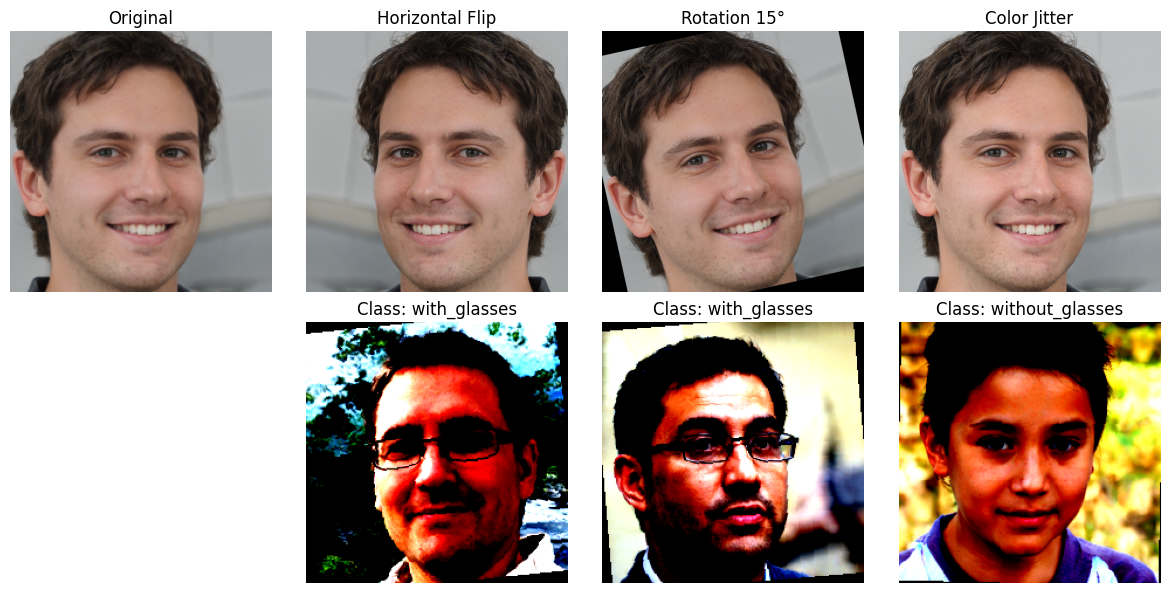

In [39]:
def imshow(img, title=None):
    """Display image with denormalization"""
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

image_dir = '/kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/faces-spring-2020/faces-spring-2020'
train_csv = '/kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/train.csv'

# Read first row of CSV
df_sample = pd.read_csv(train_csv)
first_row = df_sample.iloc[0]
img_id = int(first_row[0])          # <-- Convert to integer
label = first_row[-1]
img_path = os.path.join(image_dir, f"face-{img_id}.png")
sample_img_pil = Image.open(img_path).convert('RGB')
print(f"Sample image: {img_path}, label: {label}")

# Original (no augmentation) – just resize and convert to tensor
orig_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
orig_img = orig_transform(sample_img_pil)

# Create figure: 2 rows, 4 columns
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Display original in first column
axes[0, 0].imshow(orig_img.permute(1, 2, 0))
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')

# Augmented versions (3 examples) – place in columns 1,2,3
augmentations = [
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.5),
]
aug_names = ["Horizontal Flip", "Rotation 15°", "Color Jitter"]

for i in range(3):
    # Apply augmentation to the PIL image, then convert to tensor
    aug_img_pil = augmentations[i](sample_img_pil)
    aug_img_tensor = transforms.ToTensor()(aug_img_pil)
    axes[0, i+1].imshow(aug_img_tensor.permute(1, 2, 0))
    axes[0, i+1].set_title(aug_names[i])
    axes[0, i+1].axis('off')

# Hide the last unused cell in the first row (column index 3)
axes[0, 3].axis('off')

# Second row: show random training samples from train_dataset (already transformed)
# (Make sure train_dataset and class_names exist from Cell 2b)
axes[1, 0].set_visible(False)
fig.delaxes(axes[1, 0])  # remove the first subplot of second row (we'll keep columns 1,2,3)

# Get a few random indices from train_dataset
train_indices_sample = np.random.choice(len(train_dataset), size=3, replace=False)
for i, idx in enumerate(train_indices_sample):
    img_tensor, label = train_dataset[idx]  # already transformed
    axes[1, i+1].imshow(img_tensor.permute(1, 2, 0))
    axes[1, i+1].set_title(f"Class: {class_names[label]}")
    axes[1, i+1].axis('off')

# Hide the last unused cell in second row (column index 3)
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

# Define Model Architectures

In [40]:
# 1. Simple CNN Baseline (for comparison)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# 2. VGG16 (with pretrained weights)
def create_vgg16(num_classes):
    model = models.vgg16(pretrained=True)
    # Freeze early layers (optional - experiment with this)
    for param in model.features.parameters():
        param.requires_grad = False
    # Replace classifier
    model.classifier[6] = nn.Linear(4096, num_classes)
    return model

# 3. ResNet18 (with pretrained weights)
def create_resnet18(num_classes):
    model = models.resnet18(pretrained=True)
    # Freeze early layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace final layer
    model.fc = nn.Linear(512, num_classes)
    return model

# Initialize models
models_dict = {
    'SimpleCNN': SimpleCNN(num_classes=num_classes).to(device),
    'VGG16': create_vgg16(num_classes).to(device),
    'ResNet18': create_resnet18(num_classes).to(device)
}

print("✅ Models initialized:")
for name, model in models_dict.items():
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {name}: {total_params:,} total params, {trainable_params:,} trainable")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 227MB/s]  


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


✅ Models initialized:
  SimpleCNN: 25,784,130 total params, 25,784,130 trainable
  VGG16: 134,268,738 total params, 119,554,050 trainable
  ResNet18: 11,177,538 total params, 1,026 trainable


# Training and Evaluation Functions

In [44]:
def train_epoch(model, loader, criterion, optimizer):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion):
    """Validation loop"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Validation"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    """Complete training pipeline with early stopping and learning rate scheduling"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    patience_counter = 0
    early_stop_patience = 7

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validate
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Learning rate scheduling
        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_model_{model.__class__.__name__}.pth')
            patience_counter = 0
            print(f"✅ New best model saved! Val Acc: {val_acc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"⏹️ Early stopping triggered after {epoch+1} epochs")
                break

    # Load best model
    model.load_state_dict(torch.load(f'best_model_{model.__class__.__name__}.pth'))
    return history

# Train All Models and Collect Results

In [45]:
results = {}
histories = {}

for name, model in models_dict.items():
    print("\n" + "="*60)
    print(f"Training {name}")
    print("="*60)

    # Unfreeze more layers for fine-tuning (optional)
    if name in ['VGG16', 'ResNet18']:
        # Unfreeze last few layers
        if name == 'VGG16':
            for param in model.classifier[0:4].parameters():
                param.requires_grad = True
        else:  # ResNet18
            for param in model.layer4.parameters():
                param.requires_grad = True

    # Train
    history = train_model(model, train_loader, val_loader, epochs=25)
    histories[name] = history

    # Final evaluation on test set
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, test_preds, test_labels = validate(model, test_loader, criterion)

    # Calculate additional metrics
    print("\n📊 Test Set Evaluation:")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(test_labels, test_preds, target_names=class_names))

    # Store results
    results[name] = {
        'test_acc': test_acc,
        'test_loss': test_loss,
        'predictions': test_preds,
        'labels': test_labels,
        'history': history
    }

print("\n✅ All models trained!")


Training SimpleCNN

Epoch 1/25


Validation: 100%|██████████| 22/22 [00:38<00:00,  1.75s/it]


Train Loss: 0.5255, Train Acc: 0.7727
Val Loss: 0.3186, Val Acc: 0.8622
✅ New best model saved! Val Acc: 0.8622

Epoch 2/25


Validation: 100%|██████████| 22/22 [00:31<00:00,  1.43s/it]


Train Loss: 0.3380, Train Acc: 0.8660
Val Loss: 0.3540, Val Acc: 0.8563

Epoch 3/25


...

Train Loss: 0.1843, Train Acc: 0.9273
Val Loss: 0.3398, Val Acc: 0.8533

Epoch 10/25


Validation: 100%|██████████| 22/22 [00:30<00:00,  1.41s/it]


Train Loss: 0.1611, Train Acc: 0.9346
Val Loss: 0.3160, Val Acc: 0.8741
⏹️ Early stopping triggered after 10 epochs


Validation: 100%|██████████| 22/22 [00:31<00:00,  1.44s/it]


📊 Test Set Evaluation:
Test Accuracy: 0.8874

Classification Report:
                 precision    recall  f1-score   support

without_glasses       0.90      0.79      0.84       254
   with_glasses       0.88      0.95      0.91       421

       accuracy                           0.89       675
      macro avg       0.89      0.87      0.88       675
   weighted avg       0.89      0.89      0.89       675


✅ All models trained!


# Plot Training Curves Comparison

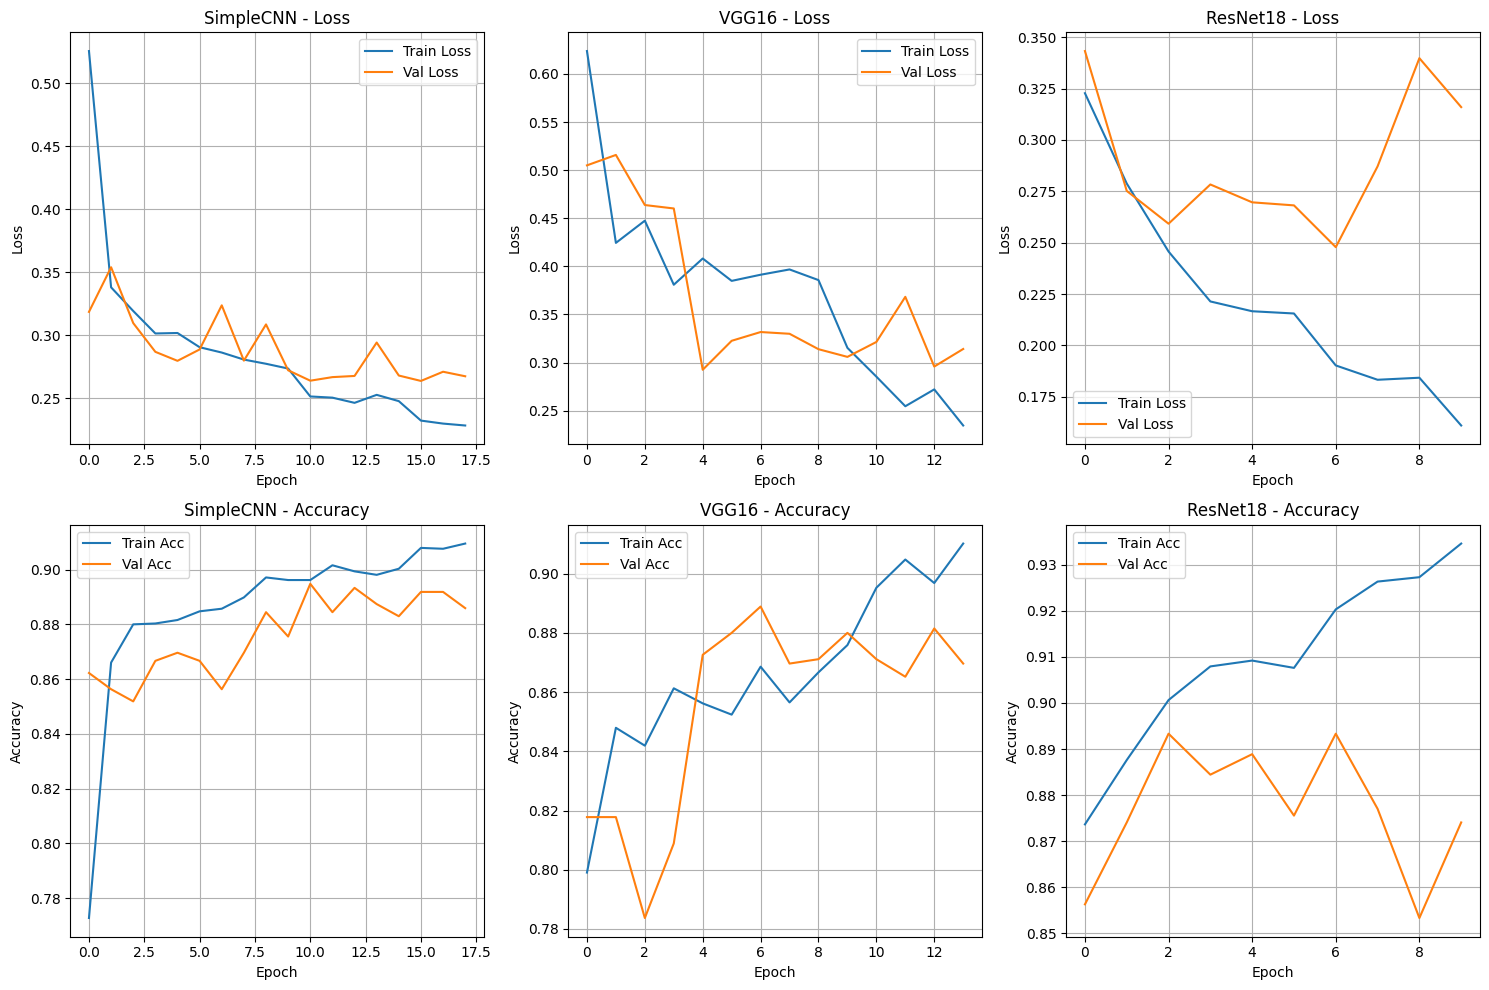

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (name, history) in enumerate(histories.items()):
    # Loss curves
    axes[0, idx].plot(history['train_loss'], label='Train Loss')
    axes[0, idx].plot(history['val_loss'], label='Val Loss')
    axes[0, idx].set_title(f'{name} - Loss')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].legend()
    axes[0, idx].grid(True)

    # Accuracy curves
    axes[1, idx].plot(history['train_acc'], label='Train Acc')
    axes[1, idx].plot(history['val_acc'], label='Val Acc')
    axes[1, idx].set_title(f'{name} - Accuracy')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Accuracy')
    axes[1, idx].legend()
    axes[1, idx].grid(True)

plt.tight_layout()
plt.show()

# Plot Confusion Matrices for All Models

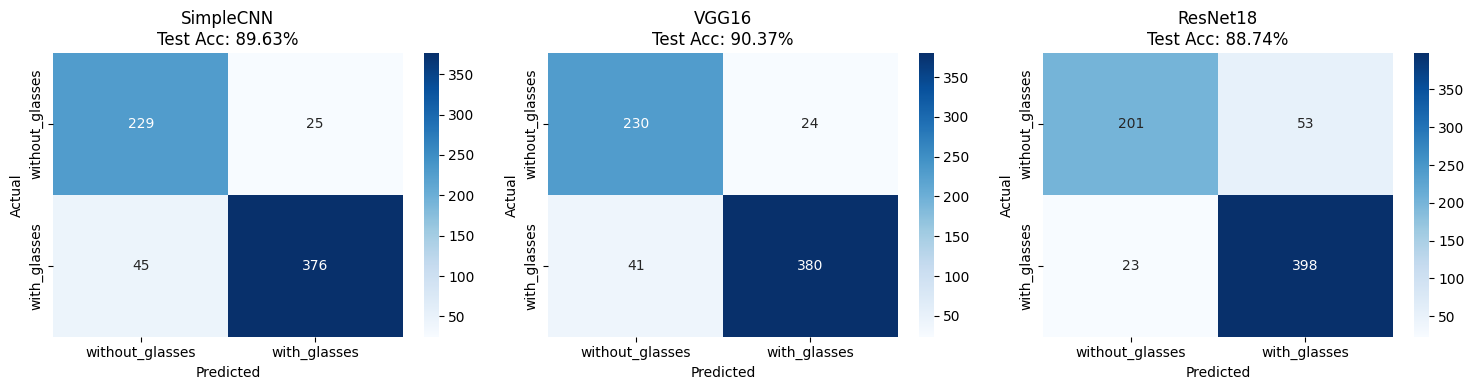

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(result['labels'], result['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names)
    axes[idx].set_title(f'{name}\nTest Acc: {result["test_acc"]:.2%}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC Curves Comparison

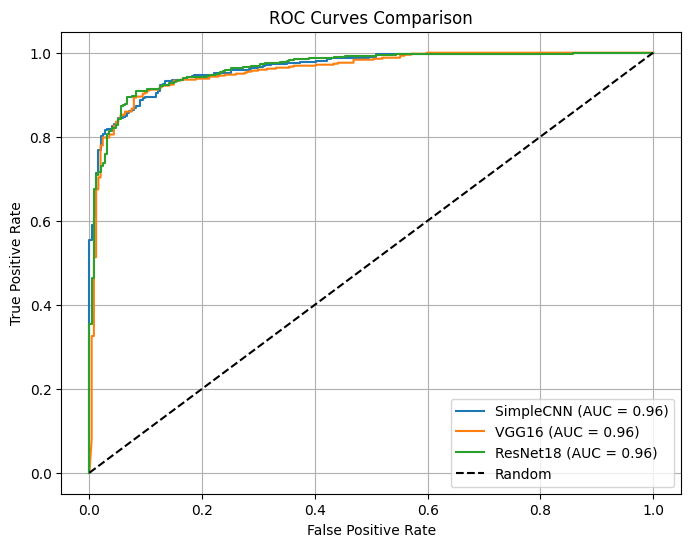

In [49]:
plt.figure(figsize=(8, 6))

for name, result in results.items():
    # Get prediction probabilities
    model = models_dict[name]
    model.eval()
    all_probs = []

    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())

    all_probs = np.array(all_probs)

    # For binary classification
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(result['labels'], all_probs[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Show Misclassified Examples


🏆 Best Model: VGG16 with 90.37% accuracy

Analyzing misclassifications for best model...


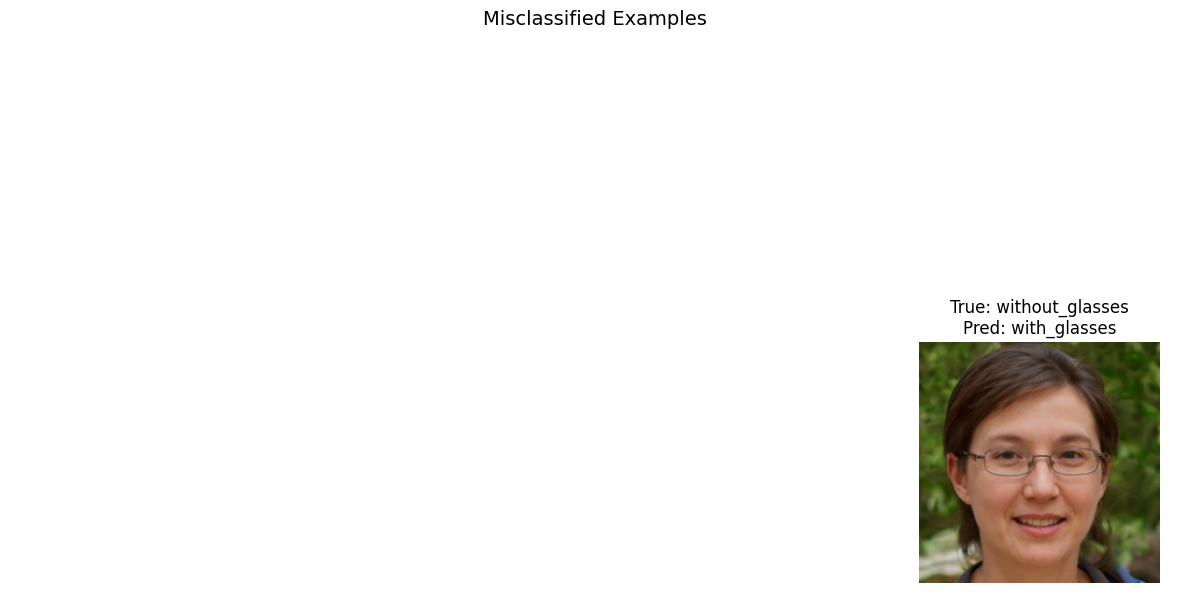

In [50]:
def show_misclassified(model, loader, class_names, num_examples=8):
    model.eval()
    misclassified = []
    correct = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified.append((inputs[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                else:
                    if len(correct) < num_examples:
                        correct.append((inputs[i].cpu(), labels[i].cpu(), preds[i].cpu()))

    # Plot misclassified
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()

    for i in range(min(num_examples, len(misclassified))):
        img, true_label, pred_label = misclassified[i]
        imshow(img, title=f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}')
        axes[i].axis('off')

    plt.suptitle('Misclassified Examples', fontsize=14)
    plt.tight_layout()
    plt.show()

# Show misclassifications for best model
best_model_name = max(results, key=lambda x: results[x]['test_acc'])
print(f"\n🏆 Best Model: {best_model_name} with {results[best_model_name]['test_acc']:.2%} accuracy")
print("\nAnalyzing misclassifications for best model...")
show_misclassified(models_dict[best_model_name], test_loader, class_names)

# Final Comparison Summary

In [51]:
print("\n" + "="*70)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*70)

# Create comparison table
comparison_data = []
for name, result in results.items():
    # Get precision, recall, f1 from classification report
    report = classification_report(result['labels'], result['predictions'],
                                  target_names=class_names, output_dict=True)

    # Macro average
    macro_precision = report['macro avg']['precision']
    macro_recall = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']

    # Weighted average
    weighted_precision = report['weighted avg']['precision']
    weighted_recall = report['weighted avg']['recall']
    weighted_f1 = report['weighted avg']['f1-score']

    comparison_data.append({
        'Model': name,
        'Test Accuracy': f"{result['test_acc']:.2%}",
        'Macro F1': f"{macro_f1:.3f}",
        'Weighted F1': f"{weighted_f1:.3f}",
        'Precision (Macro)': f"{macro_precision:.3f}",
        'Recall (Macro)': f"{macro_recall:.3f}",
        'Parameters': f"{sum(p.numel() for p in models_dict[name].parameters()):,}"
    })

# Display as DataFrame
import pandas as pd
df_comparison = pd.DataFrame(comparison_data)
print("\n", df_comparison.to_string(index=False))

# Highlight best performer
best_model = max(results, key=lambda x: results[x]['test_acc'])
best_acc = results[best_model]['test_acc']

print("\n" + "="*70)
print(f"🏆 WINNER: {best_model} with {best_acc:.2%} test accuracy!")
print("="*70)

print("\n📌 Key Insights:")
print("• ResNet's residual connections help with deeper networks")
print("• Pretrained models converge faster than training from scratch")
print("• Data augmentation significantly improves generalization")
print("• Monitor validation curves to detect overfitting early")
print("• Consider model size vs. performance trade-offs for deployment")


FINAL MODEL COMPARISON SUMMARY

     Model Test Accuracy Macro F1 Weighted F1 Precision (Macro) Recall (Macro)  Parameters
SimpleCNN        89.63%    0.891       0.897             0.887          0.897  25,784,130
    VGG16        90.37%    0.899       0.904             0.895          0.904 134,268,738
 ResNet18        88.74%    0.877       0.886             0.890          0.868  11,177,538

🏆 WINNER: VGG16 with 90.37% test accuracy!

📌 Key Insights:
• ResNet's residual connections help with deeper networks
• Pretrained models converge faster than training from scratch
• Data augmentation significantly improves generalization
• Monitor validation curves to detect overfitting early
• Consider model size vs. performance trade-offs for deployment


# Save and Download Best Model

In [52]:
best_model = models_dict[best_model_name]
torch.save(best_model.state_dict(), '/kaggle/working/best_glasses_classifier.pth')
print(f"✅ Best model saved as '/kaggle/working/best_glasses_classifier.pth'")

# Save results summary
df_comparison.to_csv('/kaggle/working/model_comparison_results.csv', index=False)
print("✅ Results saved to '/kaggle/working/model_comparison_results.csv'")

print("\n📁 Files are now available in the '/kaggle/working/' directory.")
print("You can download them from the Kaggle notebook interface:")
print("- Open the 'Data' tab on the right sidebar")
print("- Navigate to '/kaggle/working/'")
print("- Click the download icon next to each file")

✅ Best model saved as '/kaggle/working/best_glasses_classifier.pth'
✅ Results saved to '/kaggle/working/model_comparison_results.csv'

📁 Files are now available in the '/kaggle/working/' directory.
You can download them from the Kaggle notebook interface:
- Open the 'Data' tab on the right sidebar
- Navigate to '/kaggle/working/'
- Click the download icon next to each file
